In [1]:
!pip install segmentation-models-pytorch torch torchvision
!wget https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip
!wget https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip
!unzip -q ISIC2018_Task1-2_Training_Input.zip
!unzip -q ISIC2018_Task1_Training_GroundTruth.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00
--2026-04-20 21:07:04--  https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 52.216.216.9, 52.217.122.145, 3.5.21.127, ...
Connecting to isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)|52.216.216.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11165358566 (10G) [application/zip]
Saving to: ‘ISIC2018_Task1-2_Training_Input.zip’

ISIC2018_Task1-2_Tr 100%[===================>]  10.40G  48.3MB/s    in 4m 18s  

2026-04-20 21:11:22 (41.3 MB/s) - ‘ISIC2018_Task1-2_Training_Input.zip’ saved [11165358566/11165358566]

--2026-04-20 21:11:22--  https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 52.217.168.177, 3.5.2

In [2]:
import torch
import segmentation_models_pytorch as smp
from torchvision import transforms

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

In [5]:
# 1. SETTINGS & HYPERPARAMETERS
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
ACTIVATION = 'sigmoid'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATA LOADING
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

In [6]:
class ISICDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        self.cache = {} # Initialize RAM cache

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Check if already in RAM cache
        if idx in self.cache:
            return self.cache[idx]

        img_name = self.images[idx]
        mask_name = img_name.replace('.jpg', '_segmentation.png')

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Store in cache
        self.cache[idx] = (image, mask)
        return image, mask

# Initialize
train_dataset = ISICDataset(
    img_dir='ISIC2018_Task1-2_Training_Input',
    mask_dir='ISIC2018_Task1_Training_GroundTruth',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

In [7]:
def get_ablated_unet(depth=5):
    # Standard U-Net has 5 levels. We can reduce this for ablation.
    # Decoder channels must match the depth (e.g., 5 levels = 5 channels)
    all_channels = (256, 128, 64, 32, 16)
    selected_channels = all_channels[:depth]

    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        encoder_depth=depth,
        decoder_channels=selected_channels,
        classes=1,
        activation='sigmoid'
    )
    return model.to(DEVICE)

# Example: Get a model with only 3 layers of depth
model = get_ablated_unet(depth=3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting Study on cuda...

--- Processing Depth: 5 ---
Fine-tuning Depth 5 for 5 epochs...
Epoch 1/5 - Loss: 0.6497
Epoch 2/5 - Loss: 0.6485
Epoch 3/5 - Loss: 0.6429
Epoch 4/5 - Loss: 0.6158
Epoch 5/5 - Loss: 0.6168
Depth 5: Mean Dice Score = 0.8452

--- Processing Depth: 4 ---
Fine-tuning Depth 4 for 5 epochs...
Epoch 1/5 - Loss: 0.6377
Epoch 2/5 - Loss: 0.6337
Epoch 3/5 - Loss: 0.6357
Epoch 4/5 - Loss: 0.6223
Epoch 5/5 - Loss: 0.6121
Depth 4: Mean Dice Score = 0.8749

--- Processing Depth: 3 ---
Fine-tuning Depth 3 for 5 epochs...
Epoch 1/5 - Loss: 0.6469
Epoch 2/5 - Loss: 0.6172
Epoch 3/5 - Loss: 0.6100
Epoch 4/5 - Loss: 0.6088
Epoch 5/5 - Loss: 0.6214
Depth 3: Mean Dice Score = 0.8593

--- Processing Depth: 2 ---
Fine-tuning Depth 2 for 5 epochs...
Epoch 1/5 - Loss: 0.6338
Epoch 2/5 - Loss: 0.6136
Epoch 3/5 - Loss: 0.6093
Epoch 4/5 - Loss: 0.6106
Epoch 5/5 - Loss: 0.6070
Depth 2: Mean Dice Score = 0.8461


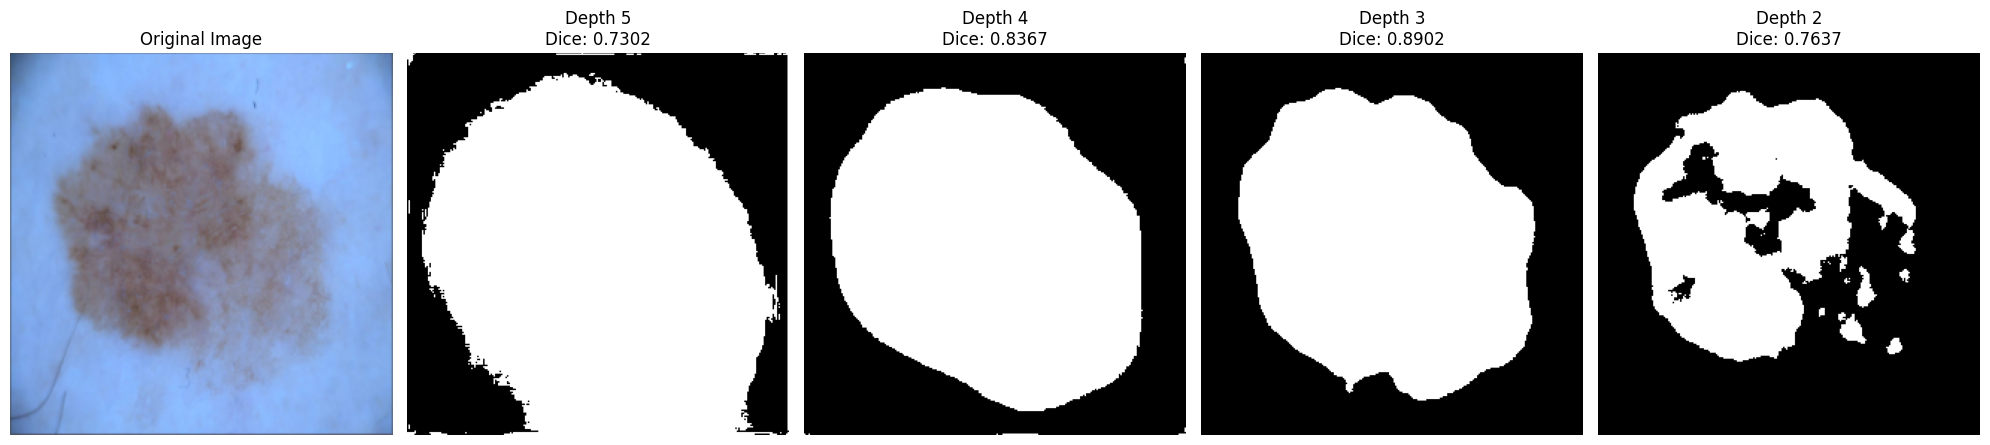

In [ ]:
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

def calculate_dice(pred, target):
    smooth = 1e-6
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# --- CONFIGURATION ---
TEST_DEPTHS = [5, 4, 3, 2]
EPOCHS_PER_DEPTH = 5
BATCH_LIMIT = 20
SAMPLE_SIZE = 50
FIXED_IMG_IDX = 42

criterion = smp.losses.DiceLoss(mode='binary')
results_report = []

print(f"Starting Study on {DEVICE}...")

# Visualization Setup
fig, axes = plt.subplots(1, len(TEST_DEPTHS) + 1, figsize=(20, 5))
test_img, test_mask = train_dataset[FIXED_IMG_IDX]
axes[0].imshow(test_img.permute(1, 2, 0).cpu())
axes[0].set_title("Original Image")
axes[0].axis('off')

for i, depth in enumerate(TEST_DEPTHS):
    print(f"\n--- Processing Depth: {depth} ---")

    # 1. Initialize Model
    model = get_ablated_unet(depth=depth)

    # 2. MINIMAL FINE-TUNING
    print(f"Fine-tuning Depth {depth} for {EPOCHS_PER_DEPTH} epochs...")
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_DEPTH)

    model.train()
    for epoch in range(EPOCHS_PER_DEPTH):
        epoch_loss = 0
        actual_batches = 0
        for batch_idx, (imgs, masks) in enumerate(train_loader):
            if batch_idx >= BATCH_LIMIT: break

            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            actual_batches += 1

        scheduler.step() # Decay learning rate
        print(f"Epoch {epoch+1}/{EPOCHS_PER_DEPTH} - Loss: {epoch_loss/actual_batches:.4f}")

    # 3. EVALUATION
    model.eval()
    total_dice = 0
    with torch.no_grad():
        for j in range(SAMPLE_SIZE):
            img, mask = train_dataset[j]
            img, mask = img.unsqueeze(0).to(DEVICE), mask.to(DEVICE)
            output = model(img)

            dice_val = calculate_dice(output, mask).item()
            total_dice += dice_val

            if j == FIXED_IMG_IDX:
                fixed_output = (output.squeeze() > 0.5).cpu().numpy()
                axes[i+1].imshow(fixed_output, cmap='gray')
                axes[i+1].set_title(f"Depth {depth}\nDice: {dice_val:.4f}")
                axes[i+1].axis('off')

    avg_dice = total_dice / SAMPLE_SIZE
    report_line = f"Depth {depth}: Mean Dice Score = {avg_dice:.4f}"
    results_report.append(report_line)
    print(f"{report_line}")

# --- SAVE OUTPUTS ---
with open("ablation_report.txt", "w") as f:
    f.write("\n".join(results_report))
plt.tight_layout()
plt.savefig("ablation_visual_comparison.png")
plt.show()